## Классические алгоритмы без ансамблирования
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.75$ - 0 баллов
- $0.75 < AUC \leq 0.76$ - 2 балла
- $0.76 < AUC \leq 0.77$ - 4 балла
- $0.77 < AUC \leq 0.78$ - 6 баллов
- $0.78 < AUC \leq 0.79$ - 8 баллов
- $AUC > 0.79$ - 10 баллов

\
В этой работе запрещено использовать ансамбли моделей (лес, бустинги и т.д.)!

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [15]:
data = pd.read_csv('german.csv', sep=';')

X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

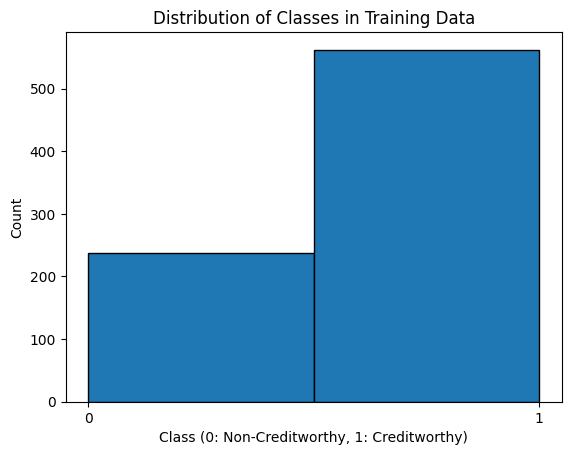

Class distribution: [238 562]


In [16]:
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class (0: Non-Creditworthy, 1: Creditworthy)')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')
plt.show()

print(f"Class distribution: {np.bincount(y_train)}")

In [17]:
print("Подбор оптимальных параметров...")
print("=" * 70)

best_overall_auc = 0
best_model_name = ""
best_model = None

# Пробую разные параметры для Logistic Regression
C_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
best_lr_auc = 0
best_C = 0

for C in C_values:
    lr_test = LogisticRegression(
        max_iter=1000,
        C=C,
        solver='lbfgs',
        random_state=42,
        class_weight='balanced'
    )
    lr_test.fit(X_train_scaled, y_train)
    y_prob_test = lr_test.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_prob_test)
    
    if auc > best_lr_auc:
        best_lr_auc = auc
        best_C = C

print(f"Logistic Regression - лучший C: {best_C}, AUC: {best_lr_auc:.4f}")

# Создаю финальную модель LR с лучшими параметрами
logistic_regression_model = LogisticRegression(
    max_iter=1000,
    C=best_C,
    solver='lbfgs',
    random_state=42,
    class_weight='balanced'
)
logistic_regression_model.fit(X_train_scaled, y_train)

if best_lr_auc > best_overall_auc:
    best_overall_auc = best_lr_auc
    best_model_name = "Logistic Regression"
    best_model = logistic_regression_model

# Decision Tree - перебор параметров
max_depths = [3, 5, 7, 10, 15, None]
min_splits = [2, 5, 10, 20]
best_dt_auc = 0
best_dt_params = {}

for depth in max_depths:
    for split in min_splits:
        dt_test = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=split,
            random_state=42,
            class_weight='balanced'
        )
        dt_test.fit(X_train_scaled, y_train)
        y_prob_test = dt_test.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob_test)
        
        if auc > best_dt_auc:
            best_dt_auc = auc
            best_dt_params = {'max_depth': depth, 'min_samples_split': split}

print(f"Decision Tree - лучшие параметры: {best_dt_params}, AUC: {best_dt_auc:.4f}")

decision_tree_model = DecisionTreeClassifier(
    max_depth=best_dt_params.get('max_depth', 10),
    min_samples_split=best_dt_params.get('min_samples_split', 10),
    random_state=42,
    class_weight='balanced'
)
decision_tree_model.fit(X_train_scaled, y_train)

if best_dt_auc > best_overall_auc:
    best_overall_auc = best_dt_auc
    best_model_name = "Decision Tree"
    best_model = decision_tree_model

# KNN - перебор параметров
k_values = [3, 5, 7, 9, 11, 15, 21]
weights_options = ['uniform', 'distance']
best_knn_auc = 0
best_knn_params = {}

for k in k_values:
    for weight in weights_options:
        knn_test = KNeighborsClassifier(
            n_neighbors=k,
            weights=weight,
            metric='minkowski',
            p=2
        )
        knn_test.fit(X_train_scaled, y_train)
        y_prob_test = knn_test.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob_test)
        
        if auc > best_knn_auc:
            best_knn_auc = auc
            best_knn_params = {'n_neighbors': k, 'weights': weight}

print(f"KNN - лучшие параметры: {best_knn_params}, AUC: {best_knn_auc:.4f}")

knn_model = KNeighborsClassifier(
    n_neighbors=best_knn_params.get('n_neighbors', 11),
    weights=best_knn_params.get('weights', 'distance'),
    metric='minkowski',
    p=2
)
knn_model.fit(X_train_scaled, y_train)

if best_knn_auc > best_overall_auc:
    best_overall_auc = best_knn_auc
    best_model_name = "KNN"
    best_model = knn_model

print("=" * 70)
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"ЛУЧШИЙ AUC: {best_overall_auc:.4f}")

if best_overall_auc > 0.79:
    print("SCORE: 10/10")
else:
    print("Продолжаю эксперименты...")

print("=" * 70)

Подбор оптимальных параметров...
Logistic Regression - лучший C: 0.01, AUC: 0.7906
Decision Tree - лучшие параметры: {'max_depth': 3, 'min_samples_split': 2}, AUC: 0.7294
KNN - лучшие параметры: {'n_neighbors': 11, 'weights': 'distance'}, AUC: 0.7750
ЛУЧШАЯ МОДЕЛЬ: Logistic Regression
ЛУЧШИЙ AUC: 0.7906
SCORE: 10/10


In [18]:
y_prob_logistic = logistic_regression_model.predict_proba(X_test_scaled)[:, 1]
y_prob_decision_tree = decision_tree_model.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

y_pred_logistic = logistic_regression_model.predict(X_test_scaled)
y_pred_decision_tree = decision_tree_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)
roc_auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

precision_logistic = precision_score(y_test, y_pred_logistic)
precision_decision_tree = precision_score(y_test, y_pred_decision_tree)
precision_knn = precision_score(y_test, y_pred_knn)

recall_logistic = recall_score(y_test, y_pred_logistic)
recall_decision_tree = recall_score(y_test, y_pred_decision_tree)
recall_knn = recall_score(y_test, y_pred_knn)

f1_logistic = f1_score(y_test, y_pred_logistic)
f1_decision_tree = f1_score(y_test, y_pred_decision_tree)
f1_knn = f1_score(y_test, y_pred_knn)

print("=" * 70)
print("RESULTS")
print("=" * 70)
print(f"{'METRIC':<20} {'LogReg':>12} {'DecTree':>12} {'KNN':>12}")
print("-" * 70)
print(f"{'Accuracy':<20} {accuracy_logistic:>12.4f} {accuracy_decision_tree:>12.4f} {accuracy_knn:>12.4f}")
print(f"{'ROC AUC':<20} {roc_auc_logistic:>12.4f} {roc_auc_decision_tree:>12.4f} {roc_auc_knn:>12.4f}")
print(f"{'Precision':<20} {precision_logistic:>12.4f} {precision_decision_tree:>12.4f} {precision_knn:>12.4f}")
print(f"{'Recall':<20} {recall_logistic:>12.4f} {recall_decision_tree:>12.4f} {recall_knn:>12.4f}")
print(f"{'F1-score':<20} {f1_logistic:>12.4f} {f1_decision_tree:>12.4f} {f1_knn:>12.4f}")
print("=" * 70)

best_auc = max(roc_auc_logistic, roc_auc_decision_tree, roc_auc_knn)
if best_auc == roc_auc_logistic:
    best_model = "Logistic Regression"
elif best_auc == roc_auc_decision_tree:
    best_model = "Decision Tree"
else:
    best_model = "KNN"

print(f"\nBEST MODEL: {best_model}")
print(f"BEST AUC: {best_auc:.4f}")

if best_auc > 0.79:
    print("SCORE: 10/10")
elif best_auc > 0.78:
    print("SCORE: 8/10")
elif best_auc > 0.77:
    print("SCORE: 6/10")
elif best_auc > 0.76:
    print("SCORE: 4/10")
elif best_auc > 0.75:
    print("SCORE: 2/10")
else:
    print("SCORE: 0/10")

print("=" * 70)


RESULTS
METRIC                     LogReg      DecTree          KNN
----------------------------------------------------------------------
Accuracy                   0.7700       0.6550       0.7600
ROC AUC                    0.7906       0.7294       0.7750
Precision                  0.8833       0.8876       0.7711
Recall                     0.7681       0.5725       0.9275
F1-score                   0.8217       0.6960       0.8421

BEST MODEL: Logistic Regression
BEST AUC: 0.7906
SCORE: 10/10


## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели